In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("final_xgboost_data_v3.csv")
df.head()

,City,PM2.5,PM10,NO,NO2,NH3,CO,SO2,O3,Month,Seasons,AQI_calculated,AQI_lag1,AQI_lag3,AQI_lag7,DayOfWeek,rolling_mean_7,AQI_tomorrow
0,Ahmedabad,154.0,181.5,15.598333,95.5,0.0,67500.0,61.5,16.0,3,Spring,326,341.0,471.0,497.0,3,392.428571,341.0
1,Ahmedabad,173.0,181.5,15.598333,104.0,0.0,93000.0,63.7,25.7,3,Spring,341,326.0,493.0,376.0,4,387.428571,407.0
2,Ahmedabad,267.0,181.5,15.598333,155.0,0.0,91000.0,105.0,14.5,3,Spring,407,341.0,341.0,389.0,5,390.000000,372.0
3,Ahmedabad,214.0,181.5,15.598333,131.0,0.0,60000.0,107.0,45.9,3,Spring,372,407.0,326.0,351.0,6,393.000000,390.0
4,Ahmedabad,237.0,181.5,15.598333,121.0,0.0,52000.0,76.3,77.3,3,Spring,390,372.0,341.0,471.0,0,381.428571,486.0


In [7]:
#GROUPED CHRONOLOGICAL SPLIT

def chronological_city_split(dataframe, test_size=0.2):
    """
    Splits data into train/test chronologically for each individual city.
    Assumes the dataframe is already sorted by Time.
    """
    train_chunks = []
    test_chunks = []
    
    for city, group in dataframe.groupby('City'):
        split_index = int(len(group) * (1 - test_size))
    
        train_chunks.append(group.iloc[:split_index])
        
        test_chunks.append(group.iloc[split_index:])
        
    return pd.concat(train_chunks), pd.concat(test_chunks)

train_df, test_df = chronological_city_split(df, test_size=0.2)

print(f"Training rows: {len(train_df)}")
print(f"esting rows: {len(test_df)}")

x_train = train_df.drop(columns=['AQI_tomorrow'])
y_train = train_df['AQI_tomorrow']

x_test = test_df.drop(columns=['AQI_tomorrow'])
y_test = test_df['AQI_tomorrow']



Training rows: 15784
esting rows: 3951


In [8]:
categorical_features = ['City', 'Seasons']
numeric_features = [col for col in x_train.columns if col not in categorical_features]

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

In [12]:
xgb_model = XGBRegressor()


In [13]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb_model)
])

In [14]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['PM2.5', 'PM10', 'NO', 'NO2',
                                                   'NH3', 'CO', 'SO2', 'O3',
                                                   'Month', 'AQI_calculated',
                                                   'AQI_lag1', 'AQI_lag3',
                                                   'AQI_lag7', 'DayOfWeek',
                                                   'rolling_mean_7']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Seasons'])])),
                ('xgb',
                 XGBRegressor(base_score=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [15]:
y_pred = model.predict(x_test)

In [16]:
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"r2_score: {r2_score(y_test, y_pred)}")

MAE : 20.924144721701005
RMSE : 33.70715514682472
r2_score: 0.7463115823661788


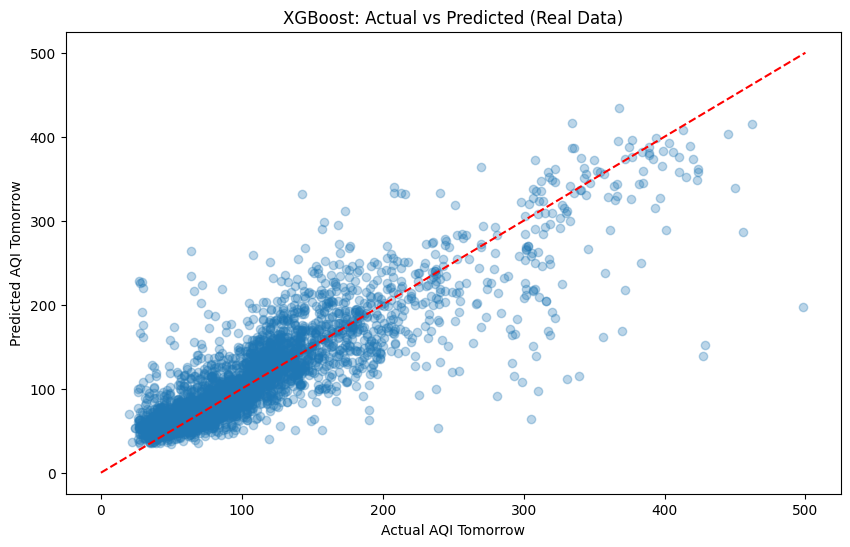

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 500], [0, 500], 'r--')
plt.xlabel('Actual AQI Tomorrow')
plt.ylabel('Predicted AQI Tomorrow')
plt.title('XGBoost: Actual vs Predicted (Real Data)')
plt.show()

In [18]:
print(x_train.columns.tolist())

['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Month', 'Seasons', 'AQI_calculated', 'AQI_lag1', 'AQI_lag3', 'AQI_lag7', 'DayOfWeek', 'rolling_mean_7']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            19735 non-null  object 
 1   PM2.5           19735 non-null  float64
 2   PM10            19735 non-null  float64
 3   NO              19735 non-null  float64
 4   NO2             19735 non-null  float64
 5   NH3             19735 non-null  float64
 6   CO              19735 non-null  float64
 7   SO2             19735 non-null  float64
 8   O3              19735 non-null  float64
 9   Month           19735 non-null  int64  
 10  Seasons         19735 non-null  object 
 11  AQI_calculated  19735 non-null  int64  
 12  AQI_lag1        19735 non-null  float64
 13  AQI_lag3        19735 non-null  float64
 14  AQI_lag7        19735 non-null  float64
 15  DayOfWeek       19735 non-null  int64  
 16  rolling_mean_7  19735 non-null  float64
 17  AQI_tomorrow    19735 non-null 

In [20]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    tscv = TimeSeriesSplit(n_splits=3)
    cv_rmse_scores = []

    for train_index, val_index in tscv.split(x_train):
        X_tr, X_val = x_train.iloc[train_index], x_train.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', XGBRegressor(**params))
        ])

        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_rmse_scores.append(rmse)

    return np.mean(cv_rmse_scores)

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\nBest Parameters Found:")
print(study.best_params)
print(f"Best Cross-Validation RMSE: {study.best_value:.2f}")

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-09 11:50:15,678] A new study created in memory with name: no-name-da456ed3-4111-4ca7-8685-9cb77caf85cb
Best trial: 0. Best value: 61.069:   1%|▍                                              | 1/100 [00:10<17:27, 10.58s/it]

[I 2026-06-09 11:50:26,258] Trial 0 finished with value: 61.0689521961557 and parameters: {'n_estimators': 1250, 'max_depth': 6, 'learning_rate': 0.0106815053818998, 'subsample': 0.7715978423490121, 'colsample_bytree': 0.6163573041333372, 'min_child_weight': 6, 'gamma': 1.710060378794016, 'reg_alpha': 4.321052872144483e-05, 'reg_lambda': 5.062878978587727e-07}. Best is trial 0 with value: 61.0689521961557.


Best trial: 0. Best value: 61.069:   2%|▉                                              | 2/100 [00:23<19:09, 11.73s/it]

[I 2026-06-09 11:50:38,802] Trial 1 finished with value: 69.77596473209675 and parameters: {'n_estimators': 1250, 'max_depth': 7, 'learning_rate': 0.09556056172854006, 'subsample': 0.5155274957102356, 'colsample_bytree': 0.8517473019510851, 'min_child_weight': 10, 'gamma': 8.585676334947816, 'reg_alpha': 4.347868005638765e-06, 'reg_lambda': 3.8817654285047166e-07}. Best is trial 0 with value: 61.0689521961557.


Best trial: 0. Best value: 61.069:   3%|█▍                                             | 3/100 [00:33<18:09, 11.23s/it]

...

[I 2026-06-09 11:55:30,571] Trial 97 finished with value: 54.652747113088594 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.025237604972820335, 'subsample': 0.5816400518486922, 'colsample_bytree': 0.8153133226200993, 'min_child_weight': 14, 'gamma': 8.963581233513958, 'reg_alpha': 6.449073859255887, 'reg_lambda': 1.637133854998094}. Best is trial 90 with value: 53.99386476065666.


Best trial: 90. Best value: 53.9939:  99%|███████████████████████████████████████████▌| 99/100 [05:15<00:00,  1.13it/s]

[I 2026-06-09 11:55:31,244] Trial 98 finished with value: 55.62318751924723 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.027681447704532066, 'subsample': 0.6403986135248163, 'colsample_bytree': 0.9004482963273691, 'min_child_weight': 12, 'gamma': 8.114341289678787, 'reg_alpha': 2.0662803873733495e-07, 'reg_lambda': 0.1970279316516932}. Best is trial 90 with value: 53.99386476065666.


Best trial: 90. Best value: 53.9939: 100%|███████████████████████████████████████████| 100/100 [05:16<00:00,  3.17s/it]

[I 2026-06-09 11:55:32,312] Trial 99 finished with value: 56.36434577568232 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.04108074787499763, 'subsample': 0.5681432223386278, 'colsample_bytree': 0.9194880991467367, 'min_child_weight': 14, 'gamma': 7.697961684123794, 'reg_alpha': 5.913512219446103, 'reg_lambda': 0.046222422127906636}. Best is trial 90 with value: 53.99386476065666.

Best Parameters Found:
{'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.027497261657833297, 'subsample': 0.573816430282209, 'colsample_bytree': 0.8676758028801996, 'min_child_weight': 13, 'gamma': 7.651150762431125, 'reg_alpha': 2.4056230222887924, 'reg_lambda': 1.8549764901985992}
Best Cross-Validation RMSE: 53.99


In [21]:
best_params = study.best_trial.params

xg_tuned = XGBRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda']
)

pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xg_tuned)
])

pipeline_tuned.fit(x_train, y_train)
y_pred_tuned = pipeline_tuned.predict(x_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_tuned):.4f}")

MAE:  19.07
RMSE: 30.60
R²:   0.7910


In [22]:
import joblib
joblib.dump(pipeline_tuned, 'aqi_pipeline_v2.pkl')

['aqi_pipeline_v2.pkl']

In [23]:
import joblib
pipeline = joblib.load('aqi_pipeline_v2.pkl')
print("Model loaded successfully!")

Model loaded successfully!


In [24]:
sample = pd.DataFrame([{
    'City': 'Delhi',
    'PM2.5': 89.5,
    'PM10': 120.3,
    'NO': 0.5,
    'NO2': 15.2,
    'NH3': 8.3,
    'CO': 0.8,
    'SO2': 5.1,
    'O3': 45.2,
    'Year': 2024,
    'Month': 6,
    'Seasons': 'Monsoon',
    'DayOfWeek': 3,
    'AQI_calculated': 145,
    'AQI_lag1': 138,
    'AQI_lag3': 130,
    'AQI_lag7': 125,
    'AQI_lag14': 118,
    'AQI_lag30': 110,
    'rolling_mean_7': 132
}])

In [25]:
pred = pipeline.predict(sample)
print(f"Predicted AQI Tomorrow: {pred[0]:.1f}")

Predicted AQI Tomorrow: 146.4


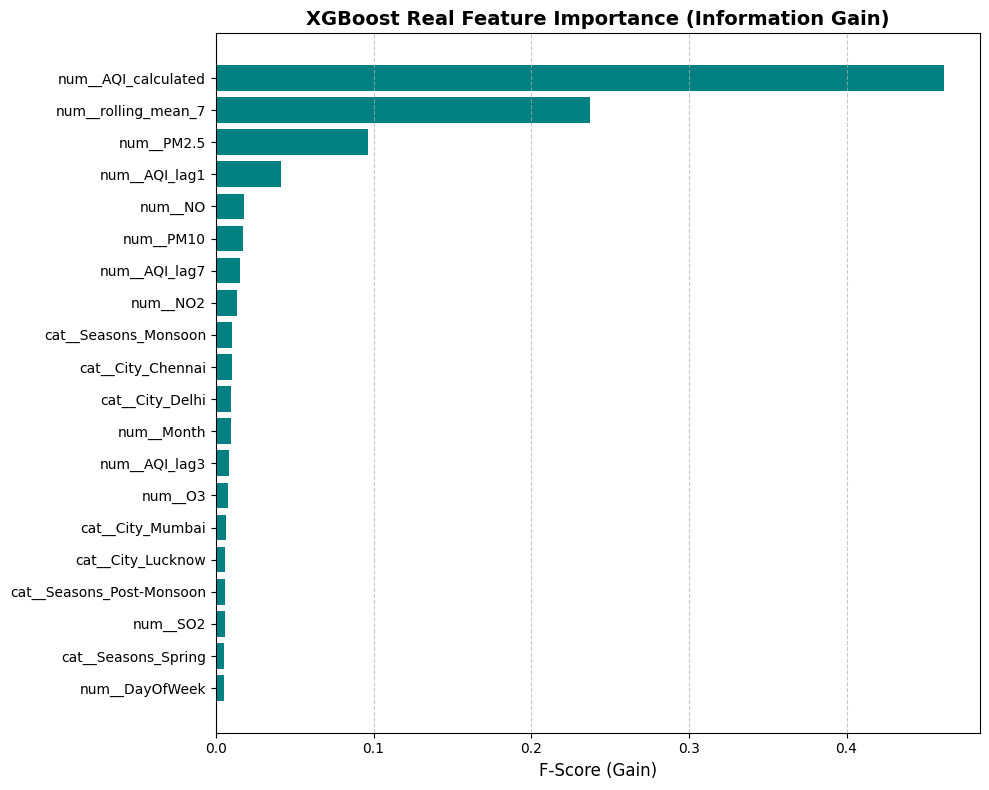

In [26]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

pipeline = joblib.load('aqi_pipeline_v2.pkl')

preprocessor = pipeline.steps[0][1]
xgb_model = pipeline.steps[-1][1]         


feature_names = preprocessor.get_feature_names_out()


importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances
}).sort_values(by='Gain', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(20), importance_df['Gain'].tail(20), color='teal')
plt.title("XGBoost Real Feature Importance (Information Gain)", fontsize=14, fontweight='bold')
plt.xlabel("F-Score (Gain)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()